# Discrete Time Model for Allen-Cahn PDE

In [1]:

import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from scipy.io import loadmat
import tensorflow_probability as tfp
from time import time
print ( "Libraries imported" )

Libraries imported


### Please check the path of the AC.mat of the IRK Weights (In Burgers PDE folder) before executing

Due to computational constraints we could only take **q = 45**, the effects of which can be seen on convergence. If can take q to be a large enough value, say 100, we can see better convergence without changing anything else.

In [2]:
burgers_shock_path = "/kaggle/input/datasets/aadharshvenkat/allen-cahn/AC.mat"
IRK_weights_path = "/kaggle/input/irk-weights/IRK_weights"

t_start = 0.1
t_end = 0.9

q = 45
N_x = 200

adam_epochs = 0
lbfgs_epochs = 50000

print ( burgers_shock_path, "\n" + IRK_weights_path )

/kaggle/input/datasets/aadharshvenkat/allen-cahn/AC.mat 
/kaggle/input/irk-weights/IRK_weights


In [3]:
data = loadmat ( burgers_shock_path )
    
t = data['tt'].flatten()[:,None]
x = data['x'].flatten()[:,None]
u = np.real ( data['uu'] ).T

t_start_index = int(t_start * 100)
t_end_index = int(t_end * 100)

dt = t[t_end_index] - t[t_start_index]

print ( t.shape, x.shape, u.shape, dt )


(201, 1) (512, 1) (201, 512) [0.4]


In [4]:
x_index = np.random.choice ( u.shape[1], N_x, replace = False ) 
x0 = x[x_index,:]
u0 = u[t_start_index:t_start_index + 1, x_index].T

x1_1 = tf.constant ( [[1.0]], dtype = tf.float32 )
x1_2 = tf.constant ( [[-1.0]], dtype = tf.float32 )

x0_tf = tf.convert_to_tensor ( x0, dtype = tf.float32 )
u0_tf = tf.convert_to_tensor ( u0, dtype = tf.float32 )

x1_1_tf = tf.convert_to_tensor ( x1_1, dtype = tf.float32 )
x1_2_tf = tf.convert_to_tensor ( x1_2, dtype = tf.float32 )

print ( x0.shape, u0.shape )
print ( x1_1_tf, x1_2_tf )

(200, 1) (200, 1)
tf.Tensor([[1.]], shape=(1, 1), dtype=float32) tf.Tensor([[-1.]], shape=(1, 1), dtype=float32)


In [5]:
tmp = np.float32 ( np.loadtxt ( f"{IRK_weights_path}/Butcher_IRK%d.txt" % (q), ndmin = 2 ) )
IRK_weights = np.reshape(tmp[0:q**2+q], (q+1,q))
IRK_times = tmp[q**2+q:]

dt = tf.convert_to_tensor ( dt, dtype = tf.float32 )

print ( IRK_weights.shape, IRK_times.shape )

(46, 45) (45, 1)


In [6]:
model = tf.keras.Sequential ( [
        tf.keras.layers.InputLayer ( input_shape = ( 1, ) ),
        tf.keras.layers.Dense ( 200, activation = 'tanh' ),
        tf.keras.layers.Dense ( 200, activation = 'tanh' ),
        tf.keras.layers.Dense ( 200, activation = 'tanh' ),
        tf.keras.layers.Dense ( 200, activation = 'tanh' ),
        tf.keras.layers.Dense ( q + 1 )
    ] )

print ( model.summary() )

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 200)            │           400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 200)            │        40,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 200)            │        40,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 200)            │        40,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 46)             │         9,246 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 130,246 (508.77 KB)

 Trainable params: 130,246 (508.77 KB)

 Non-trainable params: 0 (0.00 B)

None


### These are our loss functions.

In [7]:
@tf.function
def SSE_n():   
    with tf.GradientTape ( persistent = True ) as tape2:
        tape2.watch ( x0_tf )
        with tf.GradientTape() as tape1:
            tape1.watch ( x0_tf )
            u1_pred = model ( x0_tf )
            u_pred = u1_pred[:, :-1]
        
        du_dx = tape1.batch_jacobian ( u_pred, x0_tf )
        du_dx = tf.squeeze ( du_dx, axis = -1 )
        
    d2u_dx2 = tape2.batch_jacobian ( du_dx, x0_tf )
    d2u_dx2 = tf.squeeze ( d2u_dx2, axis = -1 )
    
    del tape2, tape1
    
    F = ( 5.0 * u_pred ) - ( 5.0* ( u_pred**3 ) ) + ( 0.0001 * d2u_dx2 )
    final_pred = u1_pred - dt * tf.matmul ( F, IRK_weights.T ) 
    
    return tf.reduce_sum ( tf.square ( final_pred - u0_tf ) )

@tf.function
def SSE_b():
    with tf.GradientTape ( persistent = True ) as tape1:
        tape1.watch ( x1_1_tf )
        tape1.watch ( x1_2_tf )

        pred1 = model ( x1_1_tf )
        pred2 = model ( x1_2_tf )

    du_dx_1 = tape1.batch_jacobian ( pred1, x1_1_tf )
    du_dx_2 = tape1.batch_jacobian ( pred2, x1_2_tf )
    du_dx_1 = tf.squeeze ( du_dx_1, axis = -1 )
    du_dx_2 = tf.squeeze ( du_dx_2, axis = -1 )

    del tape1

    return tf.reduce_sum ( tf.square ( pred1 - pred2 ) + tf.square ( du_dx_1 - du_dx_2 ) )

In [8]:

# Functions for lbfgs 

# Flatten our model weights into a single vector

func_call = 1
start = time()

def pack_weights ( vars ):
    return tf.concat ( [ tf.reshape ( v, [-1] ) for v in vars ], axis = 0 )

# Unflatten weights

def unpack_weights ( vars, flat ):
    idx = 0
    for v in vars:
        size = tf.size ( v )
        shape = v.shape
        v.assign ( tf.reshape ( flat[idx:idx+size], shape ) )
        idx += size

# passing gradients for lbfgs 

def value_and_gradients ( flat_weights ):
    global func_call, start
    
    unpack_weights ( model.trainable_variables, flat_weights )

    with tf.GradientTape() as tape:
        loss_n = SSE_n()
        loss_b = SSE_b()
        loss = loss_n + loss_b

    if ( func_call % 1000 == 0 ):
        print ( "INFO: LBFGS Call {} reached, SSE_n : {}, SSE_b: {}, Time: {}".format ( str ( func_call ), str ( float ( loss_n ) ), str ( float ( loss_b ) ), str ( float ( time() - start ) ) ) )
        model.save_weights ( "ac_latest.weights.h5" )
    func_call += 1

    grads = tape.gradient ( loss, model.trainable_variables )
    return loss, pack_weights ( grads )


#### Training.

In [9]:
# Training with adam

print ( "INFO: Training Started" )

opt = tf.keras.optimizers.Adam ( learning_rate = 0.001 )

for epoch in range ( 1, adam_epochs + 1 ):
    with tf.GradientTape() as tape:
        loss_n = SSE_n()
        loss_b = SSE_b()
        loss = loss_n + loss_b
    grads = tape.gradient ( loss, model.trainable_variables )
    opt.apply_gradients ( zip ( grads, model.trainable_variables ) )
    
    if ( epoch % 100 == 0 ):
        print ( "INFO: Adam Epoch {} reached, SSE_n : {}, SSE_b: {}, Time: {}".format ( str ( epoch ), str ( float ( loss_n ) ), str ( float ( loss_b ) ), str ( float ( time() - start ) ) ) )
        model.save_weights ( "ac_latest.weights.h5" )

print ( "INFO: Training with Adam done" )


INFO: Training Started
INFO: Training with Adam done


In [10]:

lbfgs_train = tfp.optimizer.lbfgs_minimize (
    value_and_gradients,
    initial_position = pack_weights ( model.trainable_variables ),
    max_iterations = lbfgs_epochs,
    tolerance = 1e-8
)

print ( "INFO: Overall Training Done" )

unpack_weights ( model.trainable_variables, lbfgs_train.position )

model.save_weights ( "ac_latest.weights.h5" )

INFO: LBFGS Call 1000 reached, SSE_n : 45.10478591918945, SSE_b: 1.1574987173080444, Time: 226.07108998298645
INFO: LBFGS Call 2000 reached, SSE_n : 2.285839319229126, SSE_b: 0.148708313703537, Time: 445.6717629432678
INFO: LBFGS Call 3000 reached, SSE_n : 0.807935357093811, SSE_b: 0.029234131798148155, Time: 665.7784881591797
INFO: LBFGS Call 4000 reached, SSE_n : 0.40173065662384033, SSE_b: 0.0195416621863842, Time: 888.5304772853851
INFO: LBFGS Call 5000 reached, SSE_n : 0.2760983109474182, SSE_b: 0.011781880632042885, Time: 1110.7221808433533
INFO: LBFGS Call 6000 reached, SSE_n : 0.2084917277097702, SSE_b: 0.006162000820040703, Time: 1332.5237412452698
INFO: LBFGS Call 7000 reached, SSE_n : 0.16185331344604492, SSE_b: 0.005485508590936661, Time: 1554.1481642723083
INFO: LBFGS Call 8000 reached, SSE_n : 0.13215553760528564, SSE_b: 0.004484263248741627, Time: 1773.6800637245178
INFO: LBFGS Call 9000 reached, SSE_n : 0.109534353017807, SSE_b: 0.00453300541266799, Time: 1992.877036333

In [11]:
def test_error():
    u_exact_end = u[t_end_index, :][:, None]
    
    u_pred = model.predict ( x )
    u_pred_end = u_pred[:, -1:]

    return np.linalg.norm ( u_pred_end - u_exact_end ) / np.linalg.norm ( u_exact_end )

print ( "\nTest error:", test_error() )

I0000 00:00:1771527226.156774      64 service.cc:152] XLA service 0x78587519f080 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1771527226.156845      64 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1771527226.389163      64 cuda_dnn.cc:529] Loaded cuDNN version 91002


16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step   

Test error: 0.007910809030733832


I0000 00:00:1771527226.789866      64 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


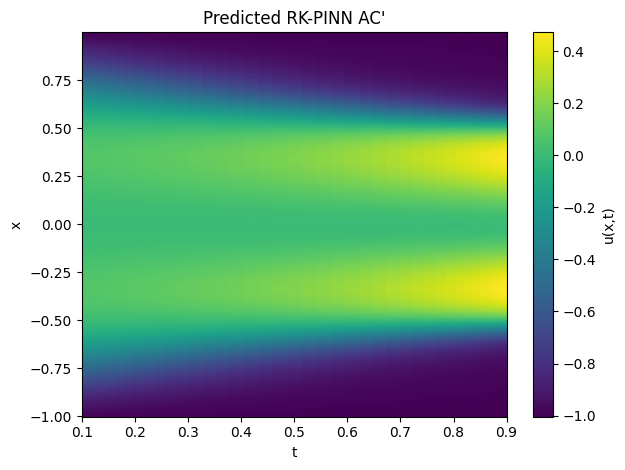

In [12]:
# Plotting the predicted output

u_pred = model.predict ( x )

t_stages = np.vstack ( ( t_start + IRK_times * (t_end - t_start), [[t_end]] ) ).flatten()
x_flat = x.flatten()

T, X = np.meshgrid ( t_stages, x_flat )
heatmap = plt.pcolormesh ( T, X, u_pred, shading = 'auto' )

plt.colorbar ( heatmap, label = "u(x,t)" )
plt.xlabel ( "t" )
plt.ylabel ( "x" )
plt.title ( "Predicted RK-PINN AC'" )

plt.tight_layout()
plt.show()

#### Plot exact solution for reference.

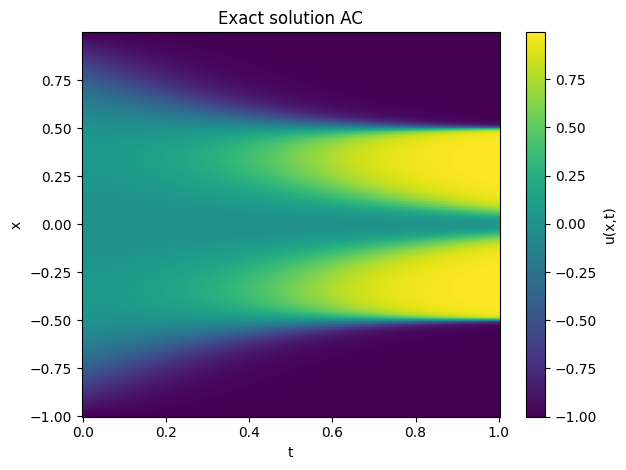

In [13]:
# Exact solution plot

T, X = np.meshgrid ( t, x, indexing = "ij" )

heatmap = plt.pcolormesh ( T, X, u, shading = "auto" )

plt.colorbar ( heatmap, label = "u(x,t)" )
plt.xlabel ( "t" )
plt.ylabel ( "x")
plt.title ( "Exact solution AC" )

plt.tight_layout()
plt.show()


##### LBFGS specific, print total number of iterations actually performed.

In [14]:
if ( lbfgs_epochs ):
    print ( "Total LBFGS iterations:", lbfgs_train.num_iterations )

Total LBFGS iterations: tf.Tensor(4447, shape=(), dtype=int32)
